In [1]:
import numpy as np
from scipy.special import comb

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

In [5]:
# prior
ps = np.linspace(0, 1, 11)  # 0.0, 0.1, ..., 1.0; The list of competing hypotheses.
prior = np.ones_like(ps) / len(ps) # Prior probabilities, defined to be uniform.

print(ps,"\n")

print(prior)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ] 

[0.09090909 0.09090909 0.09090909 0.09090909 0.09090909 0.09090909
 0.09090909 0.09090909 0.09090909 0.09090909 0.09090909]


In [7]:
# observed data
k = 3  # number of tea drinkers
n = 5  # number of people surveyed

In [11]:
# likelihood
binom_coeff = comb(n, k) # Calculate the binomial coefficient.

likelihood = (
    binom_coeff 
    * (ps ** k) 
    * ((1 - ps) ** (n - k))
)

# unnormalized posterior
unnormalized_posterior = prior * likelihood

# normalize the posterior
posterior = unnormalized_posterior / unnormalized_posterior.sum()

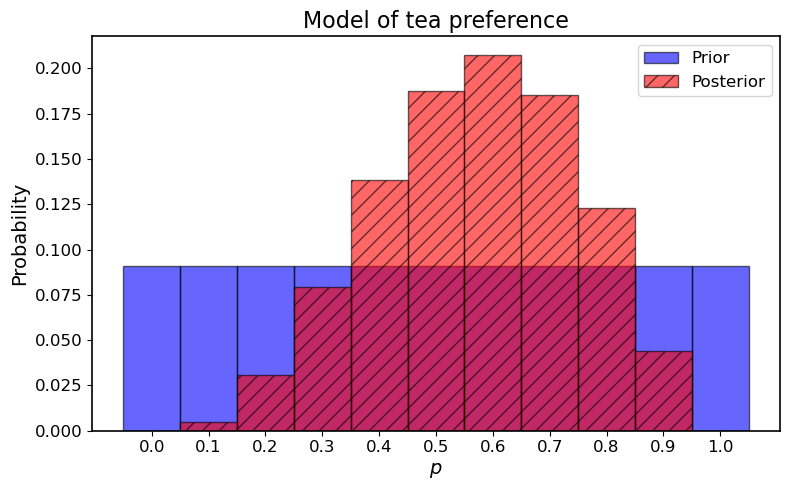

In [13]:
width = 0.1

plt.figure(figsize=(8, 5))

plt.bar(ps, prior, width=width, color='blue', alpha=0.6, label='Prior', align='center', edgecolor="k")
plt.bar(ps, posterior, width=width, color='red', alpha=0.6, label='Posterior', align='center', edgecolor="k", hatch="//")

plt.xlabel(r'$p$')
plt.ylabel('Probability')
plt.title('Model of tea preference')
plt.xticks(ps)
plt.legend()
plt.tight_layout()
plt.show()

# Code to generate illustrations

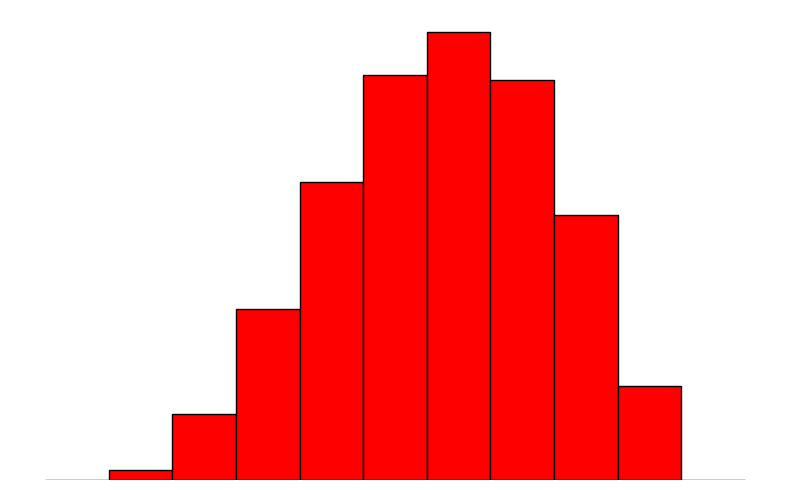

In [14]:
width = 0.1

plt.figure(figsize=(8, 5))

# plt.bar(ps, prior, width=width, color='#0000FF', alpha=1, label='Prior', align='center', edgecolor="k")
plt.bar(ps, posterior, width=width, color='#FF0000', alpha=1, label='Prior', align='center', edgecolor="k")
plt.bar(ps, posterior, width=width, color='red', alpha=0., label='Posterior', align='center')
plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
import matplotlib as mpl

mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

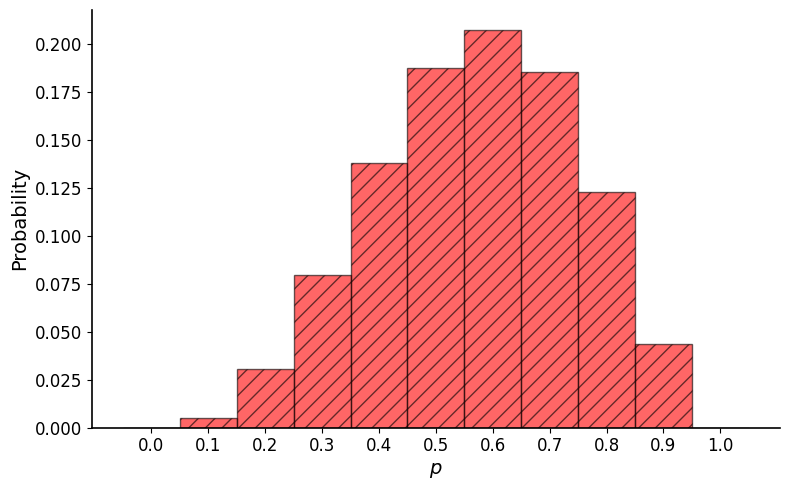

In [8]:
width = 0.1

plt.figure(figsize=(8, 5))

# plt.bar(ps, prior, width=width, color='blue', alpha=0.6, label='Prior', align='center', edgecolor="k")
plt.bar(ps, posterior, width=width, color='red', alpha=0.6, label='Posterior', align='center', edgecolor="k", hatch="//")

plt.xlabel(r'$p$')
plt.ylabel('Probability')
# plt.title('Model of tea preference')
plt.xticks(ps)
# plt.legend()
plt.tight_layout()
plt.show()

In [5]:
ps

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [6]:
posterior[ps >= 0.8].sum()

np.float64(0.16663666366636656)

In [9]:
posterior[(ps <= 0.4) * (ps >= 0.2)].sum()

np.float64(0.24836483648364843)

In [12]:
posterior[np.isclose(ps, 0.6)]

array([0.20738074])

In [5]:
def compute_posterior(prior, n, k):
    # likelihood
    binom_coeff = comb(n, k)
    likelihood = binom_coeff * (ps ** k) * ((1 - ps) ** (n - k))
    
    # unnormalized posterior
    unnormalized_posterior = prior * likelihood
    
    # normalize the posterior
    return unnormalized_posterior / unnormalized_posterior.sum()

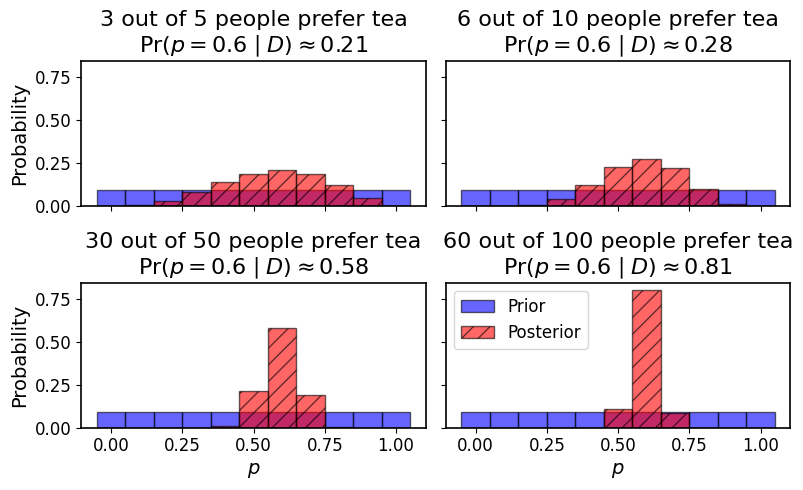

In [16]:
data = [(5, 3), (10, 6), (50, 30), (100, 60)]

fig, ax = plt.subplots(2, 2, figsize=(8, 5), sharex=True, sharey=True)

for i, (n, k) in enumerate(data):
    this_ax = ax[i // 2][i % 2]
    posterior = compute_posterior(prior, n, k)

    this_ax.bar(ps, prior, width=width, color='blue', alpha=0.6, label='Prior', align='center', edgecolor="k")
    this_ax.bar(ps, posterior, width=width, color='red', alpha=0.6, label='Posterior', align='center', edgecolor="k", hatch="//")

    this_ax.set_title(f"{k} out of {n} people prefer tea\n" + r"$\Pr(p = 0.6 \mid D) \approx$" + f"{posterior[6]:.2f}")

ax[1, 1].legend()

ax[0, 0].set_ylabel("Probability")
ax[1, 0].set_ylabel("Probability")

ax[1, 0].set_xlabel(r"$p$")
ax[1, 1].set_xlabel(r"$p$")

plt.tight_layout()
plt.show()

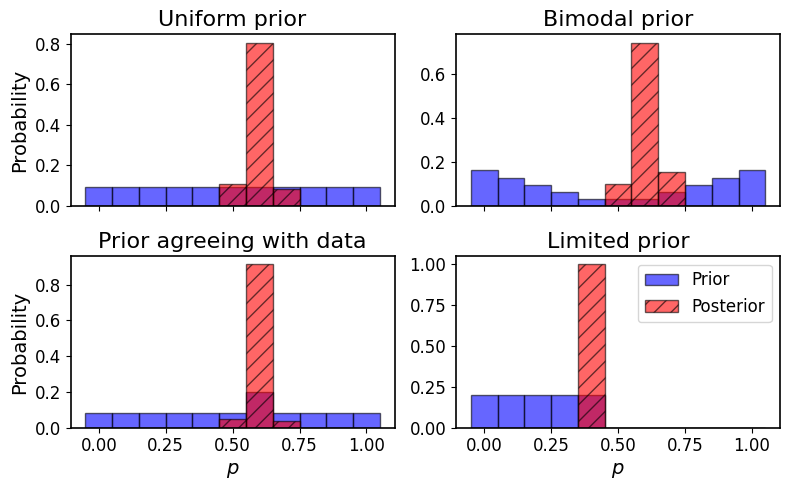

In [8]:
priors = [
    np.ones_like(ps) / len(ps),  # uniform
    np.array([5, 4, 3, 2, 1, 1, 1, 2, 3, 4, 5]) / np.array([5, 4, 3, 2, 1, 1, 1, 2, 3, 4, 5]).sum(),  # bimodal
    np.array([0.08] * 6 + [0.2] + [0.08] * 4),  # right intuition
    np.array([0.2] * 5 + [0] * 6)  # not open-minded enough
]
descriptions = [
    "Uniform prior",
    "Bimodal prior",
    "Prior agreeing with data",
    "Limited prior",
]

fig, ax = plt.subplots(2, 2, figsize=(8, 5), sharex=True)

for i, prior in enumerate(priors):
    this_ax = ax[i // 2][i % 2]
    # posterior = compute_posterior(prior, 5, 3)
    posterior = compute_posterior(prior, 100, 60)

    this_ax.bar(ps, prior, width=width, color='blue', alpha=0.6, label='Prior', align='center', edgecolor="k")
    this_ax.bar(ps, posterior, width=width, color='red', alpha=0.6, label='Posterior', align='center', edgecolor="k", hatch="//")

    this_ax.set_title(descriptions[i])

ax[1, 1].legend()

ax[0, 0].set_ylabel("Probability")
ax[1, 0].set_ylabel("Probability")

ax[1, 0].set_xlabel(r"$p$")
ax[1, 1].set_xlabel(r"$p$")

plt.tight_layout()
plt.show()